Choosing from all possible events
C:\Users\Hangeulkim\anaconda3\Lib\site-packages\moabb\datasets\download.py:97: RuntimeWarning: Setting non-standard config type: "MNE_DATASETS_BNCI_PATH"
  set_config(key, get_config("MNE_DATA"))
C:\Users\Hangeulkim\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                              | 0.00/42.8M [00:00<?, ?B/s]

SHA256 hash of downloaded file: 054f02e70cf9c4ada1517e9b9864f45407939c1062c6793516585c6f511d0325
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
C:\Users\Hangeulkim\anaconda3\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'lampx.tugraz.at'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  0%|                                              | 0.00/43.8M [00:00<?, ?B/s]

SHA256 hash of downloaded file: 53d415f39c3d7b0c88b894d7b08d99bcdfe855ede63831d3691af1a45607fb62
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


Shape: (576, 22, 1001)
Classes: {np.str_('tongue'), np.str_('feet'), np.str_('right_hand'), np.str_('left_hand')}


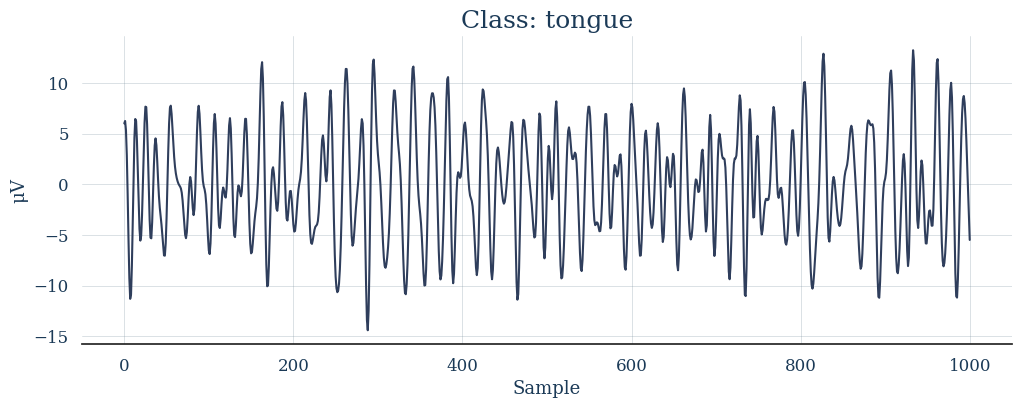

In [1]:
# day03/02_motor_imagery.ipynb
from moabb.datasets import BNCI2014_001  # = BCI Competition IV 2a
from moabb.paradigms import MotorImagery

# 1) 데이터셋 객체 (자동 다운로드)
dataset = BNCI2014_001()
dataset.subject_list = [1]  # 첫 번째 피험자만 (속도)

# 2) 패러다임 정의 (4-class, 8-30Hz 필터)
paradigm = MotorImagery(n_classes=4, fmin=8, fmax=30)

# 3) 데이터 추출 (X: EEG, y: 라벨, metadata: 세션 정보)
X, y, metadata = paradigm.get_data(dataset=dataset, subjects=[1])
print("Shape:", X.shape)  # (trials, channels, samples)
print("Classes:", set(y))  # {'feet', 'left_hand', 'right_hand', 'tongue'}

# 4) 한 trial 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(X[0, 0, :])  # 첫 trial, 첫 채널
plt.title(f"Class: {y[0]}")
plt.xlabel("Sample"); plt.ylabel("μV"); plt.show()